In [1]:
library(mgcv)
set.seed(123)

norm_data = read.csv("Data/Processed/nba_normal_scorers_filtered.csv")
# norm_data = norm_data[sample(nrow(norm_data), 900), ]

norm_data = subset(norm_data, select = -c(Player, Team, Pos, Awards, AllStarSelection, Rk, Year))

norm_data = na.omit(norm_data)

n = floor(0.8 * nrow(norm_data))
index = sample(seq_len(nrow(norm_data)), size = n)

norm.train = norm_data[index, ]
norm.test = norm_data[-index, ]

head(norm.train)
summary(norm.train)

Loading required package: nlme

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,X3P.,⋯,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Salary
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
511,32,55,7,17.3,2.2,5.2,0.433,0.7,1.5,0.439,⋯,0.3,1.3,1.6,2.4,0.6,0.2,1.2,1.0,6.7,4110433
568,27,29,4,10.9,1.9,3.9,0.496,0.1,0.5,0.200,⋯,0.9,1.7,2.7,0.1,0.1,0.5,0.5,1.8,4.6,2294633
209,24,37,12,24.5,1.8,4.4,0.414,0.6,1.9,0.324,⋯,0.5,1.8,2.3,2.1,1.1,0.1,0.8,1.6,4.6,4906243
645,20,15,1,5.6,0.7,1.8,0.407,0.3,0.7,0.400,⋯,0.4,0.7,1.1,0.3,0.2,0.3,0.3,0.7,1.9,1849950
229,25,42,5,13.5,1.3,3.2,0.406,0.9,2.6,0.351,⋯,0.9,1.7,2.6,0.4,0.1,0.5,0.2,1.1,3.7,881609
1203,32,68,40,24.4,3.9,9.4,0.411,1.4,4.2,0.333,⋯,0.4,1.8,2.1,3.4,0.7,0.1,1.7,1.7,10.2,12147949


      Age              G               GS              MP       
 Min.   :19.00   Min.   : 1.00   Min.   : 0.00   Min.   : 2.00  
 1st Qu.:22.00   1st Qu.:24.00   1st Qu.: 0.00   1st Qu.:12.03  
 Median :24.00   Median :48.00   Median : 5.00   Median :17.95  
 Mean   :25.46   Mean   :44.33   Mean   :18.51   Mean   :18.79  
 3rd Qu.:28.00   3rd Qu.:65.00   3rd Qu.:31.00   3rd Qu.:25.80  
 Max.   :43.00   Max.   :84.00   Max.   :83.00   Max.   :43.50  
       FG             FGA              FG.              X3P        
 Min.   :0.000   Min.   : 0.500   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:1.400   1st Qu.: 3.400   1st Qu.:0.3990   1st Qu.:0.3000  
 Median :2.500   Median : 5.600   Median :0.4400   Median :0.7000  
 Mean   :2.947   Mean   : 6.499   Mean   :0.4456   Mean   :0.9073  
 3rd Qu.:4.000   3rd Qu.: 8.600   3rd Qu.:0.4920   3rd Qu.:1.3000  
 Max.   :8.800   Max.   :19.400   Max.   :0.7470   Max.   :4.0000  
      X3PA            X3P.             X2P             X2PA       
 M


Family: gaussian 
Link function: identity 

Formula:
Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB + STL + BLK

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19907038    1465515 -13.584  < 2e-16 ***
Age            727764      43630  16.681  < 2e-16 ***
FG            1089547     242777   4.488 7.92e-06 ***
AST           1194561     183738   6.501 1.18e-10 ***
DRB           1005418     221998   4.529 6.55e-06 ***
STL            708434     802363   0.883    0.377    
BLK            902484     620660   1.454    0.146    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F  p-value    
s(MP)  6.661  7.819 5.834 1.03e-06 ***
s(X3P) 8.850  8.990 6.674  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.585   Deviance explained = 59.3%
GCV = 3.848e+13  Scale est. = 3.774e+13  n = 1170

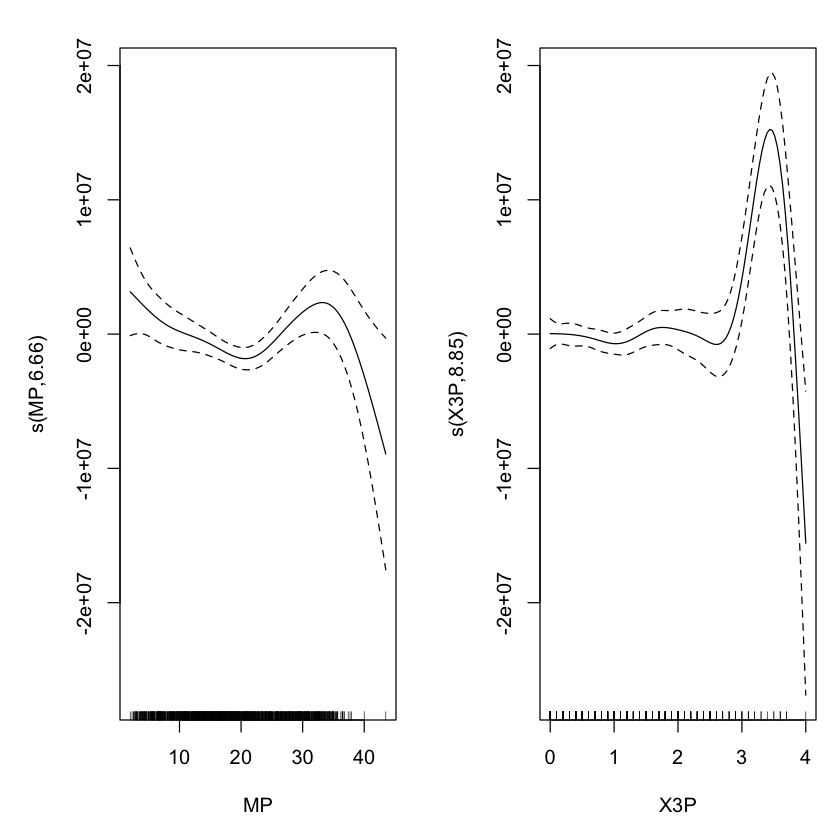

In [ ]:
gam_mod_sal = gam(Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB + STL + BLK, data = norm.train)

# Summary of the model
summary(gam_mod_sal)

# Plot the smooth terms
plot.gam(gam_mod_sal, pages = 1)


Family: gaussian 
Link function: identity 

Formula:
Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19478242    1394552 -13.967  < 2e-16 ***
Age            726211      43588  16.661  < 2e-16 ***
FG            1096160     242242   4.525 6.66e-06 ***
AST           1205566     165795   7.271 6.56e-13 ***
DRB           1135233     201502   5.634 2.21e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df     F  p-value    
s(MP)  6.576  7.745 5.727 1.22e-06 ***
s(X3P) 8.852  8.990 6.791  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.585   Deviance explained = 59.2%
GCV = 3.845e+13  Scale est. = 3.7778e+13  n = 1170

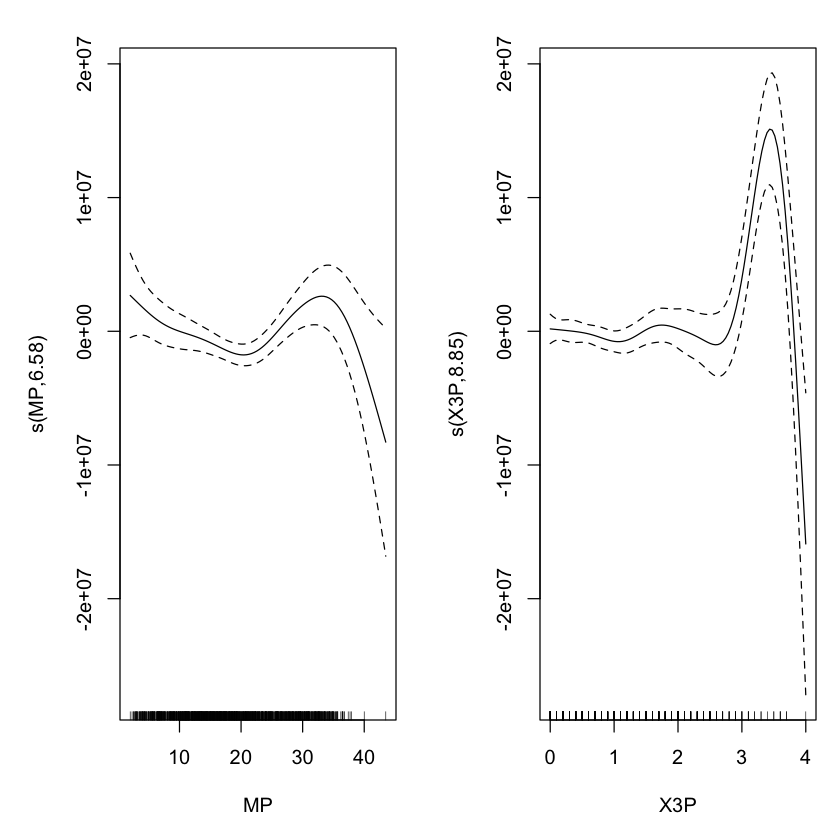

In [ ]:
gam_mod_sal_red = gam(Salary ~ Age + s(MP) + FG + s(X3P) + AST + DRB , data = norm.train)

# Summary of the model
summary(gam_mod_sal_red)

# Plot the smooth terms
plot.gam(gam_mod_sal_red, pages = 1)

In [ ]:
anova(gam_mod_sal_red, gam_mod_sal, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1148.265,4.342886e+16,NA,NA,NA
2,1146.191,4.330621e+16,2.073684,1.22648e+14,0.2077929


In [ ]:
predicted_salary_gam = predict(gam_mod_sal_red, newdata = norm.test)
actual_salary_gam = norm.test$Salary

mae_value_gam = mae(actual_salary_gam, predicted_salary_gam)
print(mae_value_gam)

[1] 4836939



Family: gaussian 
Link function: identity 

Formula:
PTS ~ FGA + s(X3PA) + FTA + s(TOV) + s(AST)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.31440    0.10090  -3.116  0.00188 ** 
FGA          1.06678    0.01801  59.219  < 2e-16 ***
FTA          0.88385    0.03640  24.282  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
          edf Ref.df     F p-value    
s(X3PA) 4.337  5.314 8.830 < 2e-16 ***
s(TOV)  8.753  8.971 7.205 < 2e-16 ***
s(AST)  5.526  6.639 3.775 0.00068 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.976   Deviance explained = 97.6%
GCV = 0.68762  Scale est. = 0.67492   n = 1170

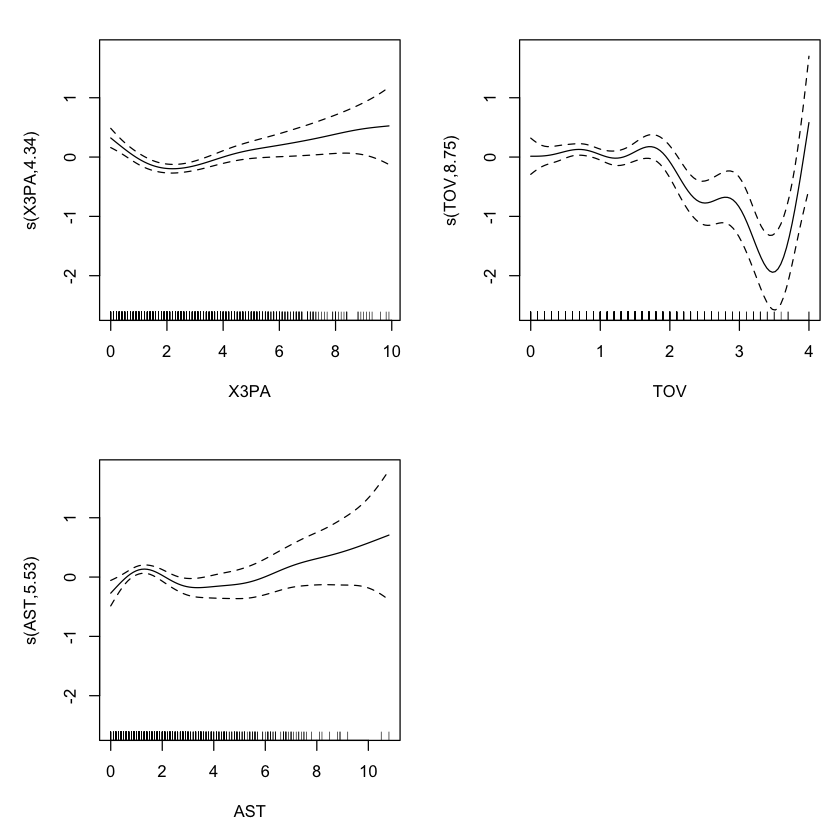

In [ ]:
gam_mod_pts = gam(PTS ~ FGA + s(X3PA) + FTA + s(TOV) + s(AST), data = norm.train)

# Summary of the model
summary(gam_mod_pts)

# Plot the smooth terms
plot.gam(gam_mod_pts, pages = 1)

In [ ]:
predicted_points_gam = predict(gam_mod_pts, newdata = norm.test)
actual_points_gam = norm.test$PTS

mae_value_gam_pts = mae(actual_points_gam, predicted_points_gam)
print(mae_value_gam_pts)

[1] 0.6301842
